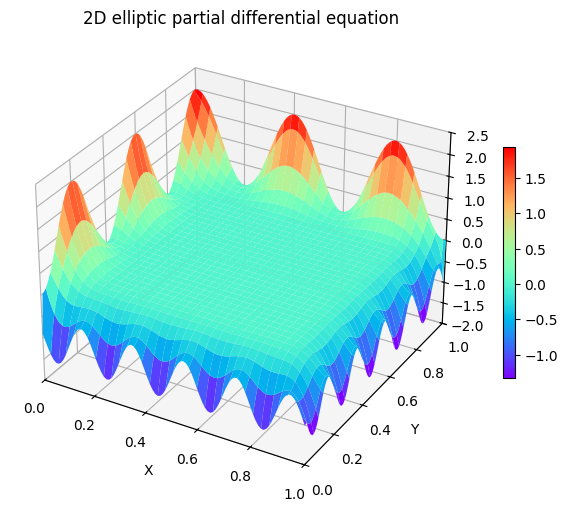

In [1]:
# finding numerical solution to the Laplacian equation u_xx+u_yy=f(x,y) 
# using the iterative relaxation method over a square domain


import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

xa, xb = 0.0, 1  # xa<x<xb
ya, yb = 0.0, 1  # ya<y<yb

h = 0.01  # spatial step size, dx = dy = 0.01
w = 0.5   # relaxation factor
grids = round((xb-xa)/h)  # number of grids in x-axis


# boundary values
u = np.zeros((grids+1, grids+1))
for i in range(grids+1):
    u[i, 0] = 1.0 + np.sin(0.5*(i-50)/np.pi)
    u[i, -1] = -1.0 + 0.5*np.sin((i-50)/np.pi)
    u[0, i] = -1.0 + 0.5*np.sin((i-50)/np.pi)
    u[-1, i] = 1.0 + np.sin(0.5*(50-i)/np.pi)


# header of VTK file
vtk_lines = [
    "# vtk DataFile Version 3.0",
    "Numerical Solution to Laplacian Equation",
    "ASCII",
    "DATASET POLYDATA",
    f"POINTS {(grids-1)*(grids-1)} float"
]


# solution by iterative relaxation method
for iter in range(100):
    for i in range(1, grids):
        for j in range(1, grids):
            u[i, j] = w/4 * (u[i-1, j] + u[i+1, j] + u[i, j-1] + u[i, j+1]) + (1-w) * u[i, j]
            if iter == 99:
                vtk_lines.append(f"{xa+i*h} {ya+j*h} {str(u[i,j])}")              # writing points into the VTK file


# generate polygons representing the surface
num_polygons = (grids-2)*(grids-2)
polygon_size = num_polygons * 5  
vtk_lines.append(f"POLYGONS {num_polygons} {polygon_size}")                        # header declaration for the polygonal surface

nodes = grids+1;

for i in range(grids-2):
    for j in range(grids-2):
        p0 = i*(grids-1) + j
        p1 = i*(grids-1) + j+1
        p2 = (i+1)*(grids-1) + j+1
        p3 = (i+1)*(grids-1) + j
        vtk_lines.append(f"4 {p0} {p1} {p2} {p3}")


# generating VTK file
with open("relaxation_2d.vtk", "w") as f:
    f.write("\n".join(vtk_lines))


# draw graph in Python
x = np.linspace(xa, xb, grids+1)
y = np.linspace(ya, yb, grids+1)
xx, yy = np.meshgrid(x, y)
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(xx, yy, u, cmap=plt.get_cmap('rainbow'))
fig.colorbar(surf, shrink=0.5)
ax.set_xlim3d(xa, xb)
ax.set_ylim3d(ya, yb)
ax.set_zlim3d(-2, 2.5)
ax.set_title("2D elliptic partial differential equation")
ax.set_xlabel("X")
ax.set_ylabel("Y")
plt.show()